# Notebook 3: NLP Feature Engineering and Reporting Quality Index

## In this notebook, I will carry out the following activities

- Load and validate the final 100-company text dataset created in Notebook 2.
- Confirm that every company has an available raw extracted-text file and processed-text file.
- Calculate eight NLP features: Word Count, ESG Keyword Density, Flesch Reading Ease, Sentiment Score, Lexical Diversity, Jargon Density, Thematic Richness and Quantitative Disclosure Density.
- Validate the calculated features for missing, invalid or inconsistent values.
- Conduct a supporting TF-IDF analysis to identify the most distinctive terms in the corporate-report corpus. TF-IDF will support the interpretation of the reports but will not be included among the eight predictive features.
- Construct an automated Reporting Quality Index using eight evidence-based reporting criteria. Each criterion will be scored from 0 to 2, where 0 indicates no evidence, 1 indicates limited or partial evidence and 2 indicates clear and substantial evidence.
- Add the eight criterion scores to produce a maximum raw score of 16 and convert the result into a Final RQI ranging from 0 to 100. A higher score will represent stronger and more complete reporting-quality evidence.
- Calculate the Final RQI independently from the eight NLP features. This separation will prevent circularity and target leakage because the NLP features will subsequently be used to predict Final RQI in Notebook 4.
- Retain TRBC Sector as the control variable and LSEG ESG Score as the external-validation variable.
- Examine and visualise the distributions of the eight NLP features and Final RQI.
- Conduct a final audit of the completed 100-company analytical dataset.
- Export the final dataset for statistical analysis and predictive modelling in Notebook 4.

**Input dataset:** `Notebook03_Final_100_Text_Dataset.xlsx`  
**Raw text folder:** `report/extracted_text`  
**Processed text folder:** `report/processed_text`  
**Sample size:** 100 companies  
**Independent variables:** Eight NLP features  
**Dependent variable:** Final Reporting Quality Index  
**Control variable:** TRBC Sector  
**External-validation variable:** LSEG ESG Score  
**Main output file:** `Notebook04_Final_Analytical_Dataset.xlsx`  

**Next stage:** Statistical analysis and predictive modelling in Notebook 4.

## 1. Set Up the Project and Load the Final Sample

I will define the project folders and load the final 100-company text dataset produced in Notebook 2.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

SEED = 42
PROJECT_COLOUR = "#1F4E78"

PROJECT_FOLDER = Path.home() / "Desktop" / "ESGProjectAnalysis"
DATA_FOLDER = PROJECT_FOLDER / "data"
OUTPUT_FOLDER = PROJECT_FOLDER / "output"
REPORT_FOLDER = PROJECT_FOLDER / "report"

EXTRACTED_TEXT_FOLDER = REPORT_FOLDER / "extracted_text"
PROCESSED_TEXT_FOLDER = REPORT_FOLDER / "processed_text"

input_file = DATA_FOLDER / "Notebook03_Final_100_Text_Dataset.xlsx"

if not input_file.exists():
    raise FileNotFoundError(f"Input file not found: {input_file}")

nlp_df = pd.read_excel(input_file)

print(f"Companies loaded: {len(nlp_df)}")
print(f"Dataset shape: {nlp_df.shape}")

display(nlp_df.head())

Companies loaded: 100
Dataset shape: (100, 39)


,Final Sample ID,Sample ID,RIC,Company Name,Company Website,Market Cap,TRBC Sector,LSEG ESG Score,Report URL,Report Year,...,Extraction Status,Extraction Error,Text File Exists,Text Eligibility,Processed Text Path,Processed Token Count,Preprocessing Status,Preprocessing Error,Processed File Exists,Processing Eligibility
0,F001,FTSE-001,ATYM.L,Atalaya Mining Copper SA,https://atalayamining.com,1.395645e+09,Basic Materials,3.033797,https://wp-atalaya-mining-2022.s3.eu-west-2.am...,2025,...,Successful,NaN,True,Eligible,C:\Users\HP\Desktop\ESGProjectAnalysis\report\...,65157,Successful,NaN,True,Eligible
1,F002,FTSE-003,CRDA.L,Croda International PLC,https://www.croda.com,4.094183e+09,Basic Materials,3.686486,https://www.croda.com/mediaassets/files/corpor...,2025,...,Successful,NaN,True,Eligible,C:\Users\HP\Desktop\ESGProjectAnalysis\report\...,87222,Successful,NaN,True,Eligible
2,F003,FTSE-004,GLEN.L,Glencore PLC,https://www.glencore.com,6.107874e+10,Basic Materials,3.812741,https://www.glencore.com/.rest/api/v1/document...,2025,...,Successful,NaN,True,Eligible,C:\Users\HP\Desktop\ESGProjectAnalysis\report\...,112590,Successful,NaN,True,Eligible
3,F004,FTSE-005,HILS.L,Hill & Smith PLC,https://hsgroup.com,2.351415e+09,Basic Materials,2.492386,https://hsgroup.com/media/jprf2zd5/annual-repo...,2025,...,Successful,NaN,True,Eligible,C:\Users\HP\Desktop\ESGProjectAnalysis\report\...,68574,Successful,NaN,True,Eligible
4,F005,FTSE-006,MNDI.L,Mondi PLC,https://www.mondigroup.com,3.330964e+09,Basic Materials,3.625000,https://www.mondigroup.com/globalassets/mondig...,2023,...,Successful,NaN,True,Eligible,C:\Users\HP\Desktop\ESGProjectAnalysis\report\...,85801,Successful,NaN,True,Eligible


## 2. Validate the Final 100-Company Dataset

I will confirm that the required variables are available, the sample contains 100 unique companies and every company has an accessible raw and processed text file.

In [2]:
required_columns = [
    "Final Sample ID",
    "Company Name",
    "TRBC Sector",
    "LSEG ESG Score",
    "Report Year",
    "Report Type",
    "Extracted Word Count",
    "Text File Path",
    "Processed Text Path"
]

missing_columns = [
    column for column in required_columns
    if column not in nlp_df.columns
]

if missing_columns:
    raise KeyError(f"Missing columns: {missing_columns}")

nlp_df["Raw Text Exists"] = nlp_df["Text File Path"].apply(
    lambda path: Path(str(path)).is_file() if pd.notna(path) else False
)

nlp_df["Processed Text Exists"] = nlp_df["Processed Text Path"].apply(
    lambda path: Path(str(path)).is_file() if pd.notna(path) else False
)

validation_summary = pd.DataFrame({
    "Validation Check": [
        "Companies loaded",
        "Unique company names",
        "Missing required values",
        "Raw text files available",
        "Processed text files available"
    ],
    "Result": [
        len(nlp_df),
        nlp_df["Company Name"].nunique(),
        int(nlp_df[required_columns].isna().sum().sum()),
        int(nlp_df["Raw Text Exists"].sum()),
        int(nlp_df["Processed Text Exists"].sum())
    ]
})

display(validation_summary.style.hide(axis="index"))

if (
    len(nlp_df) != 100
    or nlp_df["Company Name"].nunique() != 100
    or nlp_df[required_columns].isna().sum().sum() > 0
    or not nlp_df["Raw Text Exists"].all()
    or not nlp_df["Processed Text Exists"].all()
):
    raise ValueError("Dataset validation failed.")

print("Final 100-company dataset validation passed.")


Validation Check,Result
Companies loaded,100
Unique company names,100
Missing required values,0
Raw text files available,100
Processed text files available,100


Final 100-company dataset validation passed.


## 3. Load the Raw and Processed Report Texts

The saved raw and processed report texts were loaded into the dataset for feature engineering and reporting-quality assessment. The original text files remained permanently stored in their respective report folders to support reproducibility and independent verification.

In [3]:
def read_text_file(file_path):
    return Path(str(file_path)).read_text(
        encoding="utf-8",
        errors="ignore"
    )

nlp_df["Raw Text"] = (
    nlp_df["Text File Path"].apply(read_text_file)
)

nlp_df["Processed Text"] = (
    nlp_df["Processed Text Path"].apply(read_text_file)
)

nlp_df["Raw Character Count"] = (
    nlp_df["Raw Text"].str.len()
)

nlp_df["Processed Token Count"] = (
    nlp_df["Processed Text"].str.split().str.len()
)

if nlp_df["Raw Text"].str.strip().eq("").any():
    raise ValueError("One or more raw text files are empty.")

if nlp_df["Processed Text"].str.strip().eq("").any():
    raise ValueError("One or more processed text files are empty.")

display(
    nlp_df[
        [
            "Company Name",
            "Raw Character Count",
            "Processed Token Count"
        ]
    ].head()
)

print("All raw and processed texts loaded successfully.")

,Company Name,Raw Character Count,Processed Token Count
0,Atalaya Mining Copper SA,679837,65157
1,Croda International PLC,899739,87222
2,Glencore PLC,1129023,112590
3,Hill & Smith PLC,711708,68574
4,Mondi PLC,892429,85801


All raw and processed texts loaded successfully.


## 4. Define the NLP Dictionaries and Analytical Tools

The sustainability themes, ESG keywords and specialist jargon terms required for feature engineering are defined. Eight thematic categories are used to measure the breadth of sustainability subjects discussed in each report. The readability and sentiment-analysis tools were also prepared.


In [4]:
%pip install -q textstat nltk

import nltk
import textstat
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("vader_lexicon", quiet=True)
sentiment_analyser = SentimentIntensityAnalyzer()

ESG_THEMES = {
    "Climate and Emissions": [
        "climate change", "carbon emission", "greenhouse gas",
        "net zero", "decarbonisation"
    ],
    "Energy": [
        "energy efficiency", "renewable energy",
        "clean energy", "energy consumption"
    ],
    "Water": [
        "water consumption", "water management",
        "water withdrawal", "water conservation"
    ],
    "Waste and Circularity": [
        "waste management", "recycling",
        "circular economy", "waste reduction"
    ],
    "Biodiversity": [
        "biodiversity", "ecosystem",
        "natural capital", "habitat"
    ],
    "Employees": [
        "employee wellbeing", "health and safety",
        "staff development", "workforce"
    ],
    "Social and Human Rights": [
        "human rights", "modern slavery",
        "community investment", "social impact"
    ],
    "Governance and Ethics": [
        "corporate governance", "business ethics",
        "board oversight", "anti-corruption"
    ]
}

ESG_KEYWORDS = sorted({
    term
    for terms in ESG_THEMES.values()
    for term in terms
})

JARGON_TERMS = [
    "materiality", "stakeholder engagement", "value creation",
    "strategic alignment", "integrated approach",
    "governance framework", "risk appetite",
    "operational resilience", "long-term value",
    "sustainable growth", "transformation programme",
    "key performance indicator"
]

THEME_MIN_MENTIONS = 3

print(f"ESG themes defined: {len(ESG_THEMES)}")
print(f"ESG keyword terms defined: {len(ESG_KEYWORDS)}")
print(f"Jargon terms defined: {len(JARGON_TERMS)}")

Note: you may need to restart the kernel to use updated packages.


C:\Users\HP\anaconda3\Lib\site-packages\nltk\metrics\association.py:26: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.stats import fisher_exact


ESG themes defined: 8
ESG keyword terms defined: 33
Jargon terms defined: 12


## 5. Calculate the Eight NLP Features

The eight NLP features are calculated from the raw and processed corporate-report texts. Density measures are expressed per 1,000 words so that reports of different lengths can be compared consistently.


In [5]:
def count_terms(text, terms):
    text = text.lower()
    return sum(
        len(re.findall(rf"\b{re.escape(term)}\b", text))
        for term in terms
    )

def calculate_sentiment(text, chunk_size=10000):
    chunks = [
        text[position:position + chunk_size]
        for position in range(0, len(text), chunk_size)
    ]

    if not chunks:
        return 0.0

    scores = [
        sentiment_analyser.polarity_scores(chunk)["compound"]
        for chunk in chunks
    ]

    return float(np.average(scores, weights=[len(chunk) for chunk in chunks]))

def calculate_nlp_features(row):
    raw_text = row["Raw Text"]
    processed_tokens = row["Processed Text"].split()

    word_count = len(re.findall(r"\b[\w'-]+\b", raw_text))
    denominator = max(word_count, 1)

    esg_mentions = count_terms(raw_text, ESG_KEYWORDS)
    jargon_mentions = count_terms(raw_text, JARGON_TERMS)

    thematic_richness = sum(
        count_terms(raw_text, terms) >= THEME_MIN_MENTIONS
        for terms in ESG_THEMES.values()
    )

    numerical_mentions = len(
        re.findall(r"\b\d+(?:[.,]\d+)*(?:%|bn|m|million|billion)?\b",
                   raw_text.lower())
    )

    return pd.Series({
        "Word Count": word_count,
        "ESG Keyword Density": esg_mentions / denominator * 1000,
        "Flesch Reading Ease": textstat.flesch_reading_ease(raw_text),
        "Sentiment Score": calculate_sentiment(raw_text),
        "Lexical Diversity": (
            len(set(processed_tokens)) / max(len(processed_tokens), 1)
        ),
        "Jargon Density": jargon_mentions / denominator * 1000,
        "Thematic Richness": thematic_richness,
        "Quantitative Disclosure Density": (
            numerical_mentions / denominator * 1000
        )
    })

feature_columns = [
    "Word Count",
    "ESG Keyword Density",
    "Flesch Reading Ease",
    "Sentiment Score",
    "Lexical Diversity",
    "Jargon Density",
    "Thematic Richness",
    "Quantitative Disclosure Density"
]

nlp_df[feature_columns] = nlp_df.apply(
    calculate_nlp_features,
    axis=1
)

display(
    nlp_df[
        ["Company Name"] + feature_columns
    ].head()
)

print("Eight NLP features calculated successfully.")

,Company Name,Word Count,ESG Keyword Density,Flesch Reading Ease,Sentiment Score,Lexical Diversity,Jargon Density,Thematic Richness,Quantitative Disclosure Density
0,Atalaya Mining Copper SA,100097.0,1.118915,19.997259,0.936436,0.074620,0.389622,7.0,63.158736
1,Croda International PLC,138145.0,1.874842,29.447269,0.901310,0.077171,1.404322,8.0,76.593434
2,Glencore PLC,171251.0,3.287572,21.688613,0.887620,0.057865,0.543063,6.0,114.697140
3,Hill & Smith PLC,111959.0,2.393733,32.278196,0.850640,0.076895,0.643093,6.0,76.572674
4,Mondi PLC,134849.0,2.721563,24.763780,0.974427,0.070570,0.652582,8.0,74.957916


Eight NLP features calculated successfully.


## 6. Validate and Save the NLP Features

The eight NLP features are checked for missing values, infinite values and invalid numerical ranges. The validated feature dataset is then saved without embedding the full report texts, because the raw and processed documents remain stored separately in the report folders.


In [6]:
for column in feature_columns:
    nlp_df[column] = pd.to_numeric(
        nlp_df[column],
        errors="coerce"
    )

range_checks = {
    "Word Count": nlp_df["Word Count"].gt(0),
    "ESG Keyword Density": nlp_df["ESG Keyword Density"].ge(0),
    "Flesch Reading Ease": nlp_df["Flesch Reading Ease"].notna(),
    "Sentiment Score": nlp_df["Sentiment Score"].between(-1, 1),
    "Lexical Diversity": nlp_df["Lexical Diversity"].between(0, 1),
    "Jargon Density": nlp_df["Jargon Density"].ge(0),
    "Thematic Richness": nlp_df["Thematic Richness"].between(0, 8),
    "Quantitative Disclosure Density":
        nlp_df["Quantitative Disclosure Density"].ge(0)
}

feature_validation = pd.DataFrame({
    "NLP Feature": feature_columns,
    "Missing Values": [
        nlp_df[column].isna().sum()
        for column in feature_columns
    ],
    "Infinite Values": [
        np.isinf(nlp_df[column]).sum()
        for column in feature_columns
    ],
    "Minimum": [
        nlp_df[column].min()
        for column in feature_columns
    ],
    "Maximum": [
        nlp_df[column].max()
        for column in feature_columns
    ],
    "Valid Range": [
        "Yes" if range_checks[column].all() else "No"
        for column in feature_columns
    ]
})

display(
    feature_validation.round(4).style.hide(axis="index")
)

if (
    feature_validation["Missing Values"].sum() > 0
    or feature_validation["Infinite Values"].sum() > 0
    or feature_validation["Valid Range"].ne("Yes").any()
):
    raise ValueError("NLP feature validation failed.")

metadata_columns = [
    "Final Sample ID",
    "Sample ID",
    "RIC",
    "Company Name",
    "TRBC Sector",
    "LSEG ESG Score",
    "Report Year",
    "Report Type",
    "Text File Path",
    "Processed Text Path"
]

feature_output_columns = [
    column for column in metadata_columns
    if column in nlp_df.columns
] + feature_columns

nlp_feature_df = nlp_df[feature_output_columns].copy()

feature_file = (
    DATA_FOLDER / "Notebook03_NLP_Feature_Dataset.xlsx"
)

nlp_feature_df.to_excel(feature_file, index=False)

print("NLP feature validation passed.")
print(f"Feature dataset saved as: {feature_file.name}")

NLP Feature,Missing Values,Infinite Values,Minimum,Maximum,Valid Range
Word Count,0,0,7131.000000,349301.000000,Yes
ESG Keyword Density,0,0,0.000000,7.150300,Yes
Flesch Reading Ease,0,0,5.958000,38.976700,Yes
Sentiment Score,0,0,0.561700,0.999600,Yes
Lexical Diversity,0,0,0.041100,0.304900,Yes
Jargon Density,0,0,0.000000,1.831800,Yes
Thematic Richness,0,0,0.000000,8.000000,Yes
Quantitative Disclosure Density,0,0,30.344100,163.203700,Yes


NLP feature validation passed.
Feature dataset saved as: Notebook03_NLP_Feature_Dataset.xlsx


## 7. Conduct the Supporting TF-IDF Analysis

TF-IDF analysis is used to identify the terms that are most distinctive across the corporate-report corpus. This analysis supports the interpretation of the reports but is not included among the eight predictive NLP features.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectoriser = TfidfVectorizer(
    lowercase=True,
    min_df=3,
    max_df=0.85,
    max_features=5000,
    sublinear_tf=True,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z-]{2,}\b"
)

tfidf_matrix = tfidf_vectoriser.fit_transform(
    nlp_df["Processed Text"]
)

mean_tfidf_scores = np.asarray(
    tfidf_matrix.mean(axis=0)
).ravel()

tfidf_results = (
    pd.DataFrame({
        "Term": tfidf_vectoriser.get_feature_names_out(),
        "Mean TF-IDF Score": mean_tfidf_scores
    })
    .sort_values("Mean TF-IDF Score", ascending=False)
    .reset_index(drop=True)
)

top_20_tfidf = tfidf_results.head(20).copy()

top_20_tfidf.to_excel(
    DATA_FOLDER / "Notebook03_TFIDF_Top_Terms.xlsx",
    index=False
)

display(
    top_20_tfidf.round(4).style.hide(axis="index")
)

print(f"Documents analysed: {tfidf_matrix.shape[0]}")
print(f"Terms retained: {tfidf_matrix.shape[1]}")

Term,Mean TF-IDF Score
lease,0.028800
vest,0.028400
salary,0.027800
consolidate,0.027400
impairment,0.026700
ifrs,0.025800
receivables,0.024500
borrowing,0.024500
workforce,0.024200
derivative,0.024000


Documents analysed: 100
Terms retained: 5000


### Analytical Interpretation of the TF-IDF Results

The TF-IDF analysis identifies the terms that are most distinctive across the 100 corporate reports, rather than simply the most frequently used words. Financial and accounting terms such as *lease*, *impairment*, *IFRS*, *receivables*, *borrowing*, *derivative*, *goodwill* and *taxation* dominate the results. This indicates that the analysed corpus is strongly influenced by the financial and statutory content of annual reports. Terms such as *vest* and *consolidate* appear in their lemmatised forms and may represent words such as *vesting*, *vested* and *consolidated* in the original reports.

Sustainability-related terms such as *workforce* and *GHG* are present but are less dominant than the financial terms. This suggests that sustainability information is incorporated within broader annual-report disclosures rather than consistently forming the principal focus of the documents. The relatively narrow range of mean TF-IDF scores, from approximately 0.022 to 0.029, also shows that no single term overwhelmingly dominates the corpus. These results provide contextual evidence about the reports but do not measure statistical significance or reporting quality directly; TF-IDF therefore remains a supporting analysis rather than a predictive NLP feature.

## 8. Visualise the Leading TF-IDF Terms

The 20 terms with the highest mean TF-IDF scores are presented in a vertical bar chart. The visualisation shows the relative prominence of distinctive terms across the 100-company report corpus.


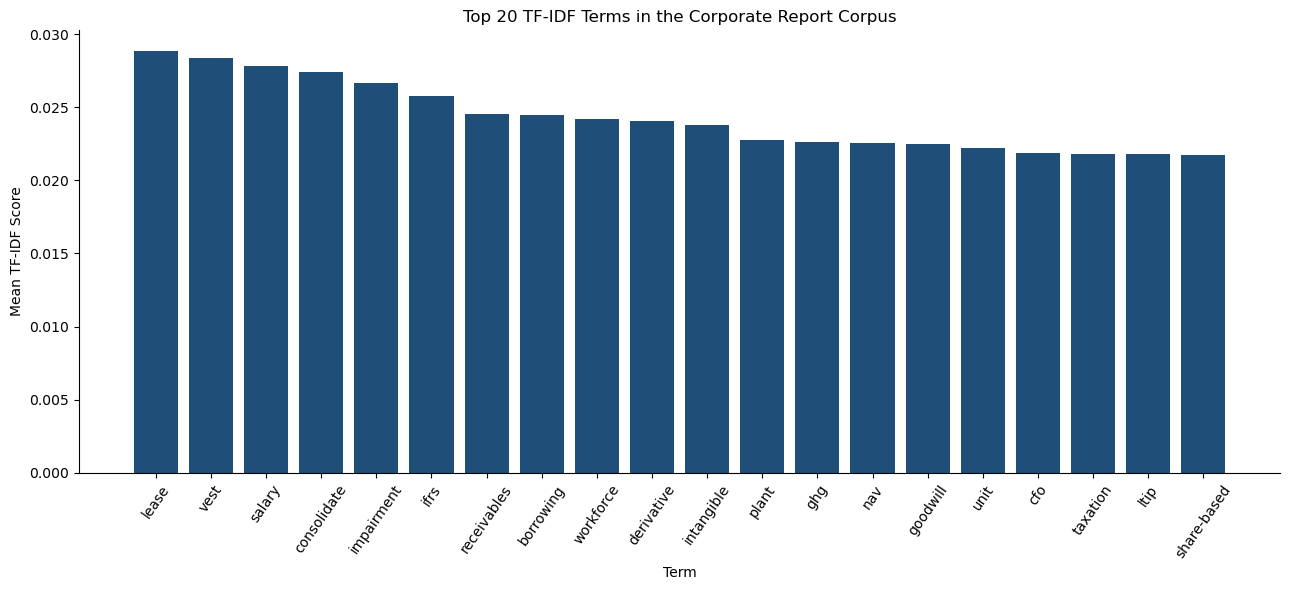

Chart saved as: Notebook03_TFIDF_Top_Terms.png


In [8]:
fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(
    top_20_tfidf["Term"],
    top_20_tfidf["Mean TF-IDF Score"],
    color=PROJECT_COLOUR
)

ax.set_title("Top 20 TF-IDF Terms in the Corporate Report Corpus")
ax.set_xlabel("Term")
ax.set_ylabel("Mean TF-IDF Score")
ax.tick_params(axis="x", rotation=55)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

tfidf_chart_file = (
    OUTPUT_FOLDER / "Notebook03_TFIDF_Top_Terms.png"
)

plt.savefig(
    tfidf_chart_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved as: {tfidf_chart_file.name}")

## 9. Define the Automated Reporting Quality Framework

Eight evidence-based reporting criteria are defined to assess the quality and completeness of each corporate report. The criteria examine governance, materiality, strategic integration, targets, quantitative indicators, comparative performance, reporting-framework alignment and external assurance.


In [9]:
RQI_CRITERIA = {
    "Governance and Accountability": [
        "board oversight",
        "sustainability committee",
        "board responsibility",
        "executive remuneration",
        "governance structure"
    ],
    "Materiality and Stakeholder Engagement": [
        "materiality assessment",
        "double materiality",
        "stakeholder engagement",
        "material topics",
        "stakeholder consultation"
    ],
    "Strategy and Risk Integration": [
        "sustainability strategy",
        "esg strategy",
        "climate-related risk",
        "sustainability risk",
        "transition plan"
    ],
    "Targets and Time Horizons": [
        "science-based target",
        "interim target",
        "short-term target",
        "medium-term target",
        "long-term target",
        "target year"
    ],
    "Quantitative Performance Indicators": [
        "key performance indicator",
        "scope 1",
        "scope 2",
        "scope 3",
        "tonnes co2e",
        "percentage reduction"
    ],
    "Comparative Performance": [
        "prior year",
        "year-on-year",
        "compared with",
        "baseline year",
        "progress against target"
    ],
    "Reporting Framework Alignment": [
        "global reporting initiative",
        "gri",
        "tcfd",
        "sasb",
        "issb",
        "un sustainable development goals"
    ],
    "External Assurance": [
        "independent assurance",
        "limited assurance",
        "reasonable assurance",
        "assurance statement",
        "external verification"
    ]
}

print(f"Reporting-quality criteria defined: {len(RQI_CRITERIA)}")

for criterion, indicators in RQI_CRITERIA.items():
    print(f"- {criterion}: {len(indicators)} evidence indicators")

Reporting-quality criteria defined: 8
- Governance and Accountability: 5 evidence indicators
- Materiality and Stakeholder Engagement: 5 evidence indicators
- Strategy and Risk Integration: 5 evidence indicators
- Targets and Time Horizons: 6 evidence indicators
- Quantitative Performance Indicators: 6 evidence indicators
- Comparative Performance: 5 evidence indicators
- Reporting Framework Alignment: 6 evidence indicators
- External Assurance: 5 evidence indicators


## 10. Calculate the Automated Reporting Quality Index

Each report is assessed against the eight reporting-quality criteria. A criterion receives 0 when no evidence indicator is identified, 1 when one or two distinct indicators are found, and 2 when three or more distinct indicators are found. The eight scores are combined and converted into a Final RQI ranging from 0 to 100.


In [10]:
def assess_rqi_criterion(text, indicators):
    text = text.lower()

    evidence = {
        indicator: len(
            re.findall(rf"\b{re.escape(indicator)}\b", text)
        )
        for indicator in indicators
    }

    matched_indicators = [
        indicator for indicator, count in evidence.items()
        if count > 0
    ]

    distinct_evidence = len(matched_indicators)
    total_mentions = sum(evidence.values())

    if distinct_evidence == 0:
        score = 0
    elif distinct_evidence <= 2:
        score = 1
    else:
        score = 2

    return total_mentions, matched_indicators, score

rqi_records = []

for _, row in nlp_df.iterrows():
    record = {}

    for criterion, indicators in RQI_CRITERIA.items():
        mentions, matched, score = assess_rqi_criterion(
            row["Raw Text"],
            indicators
        )

        record[f"{criterion} Evidence Count"] = mentions
        record[f"{criterion} Evidence Found"] = ", ".join(matched)
        record[f"{criterion} Score"] = score

    rqi_records.append(record)

rqi_results = pd.DataFrame(
    rqi_records,
    index=nlp_df.index
)

nlp_df = pd.concat(
    [nlp_df, rqi_results],
    axis=1
)

rqi_score_columns = [
    f"{criterion} Score"
    for criterion in RQI_CRITERIA
]

nlp_df["Raw RQI Score"] = (
    nlp_df[rqi_score_columns].sum(axis=1)
)

nlp_df["Final RQI"] = (
    nlp_df["Raw RQI Score"] / 16 * 100
)

display(
    nlp_df[
        ["Company Name", "Raw RQI Score", "Final RQI"]
    ].head()
)

print("Automated Reporting Quality Index calculated.")
print(f"Minimum Final RQI: {nlp_df['Final RQI'].min():.2f}")
print(f"Maximum Final RQI: {nlp_df['Final RQI'].max():.2f}")

,Company Name,Raw RQI Score,Final RQI
0,Atalaya Mining Copper SA,10,62.50
1,Croda International PLC,14,87.50
2,Glencore PLC,10,62.50
3,Hill & Smith PLC,10,62.50
4,Mondi PLC,13,81.25


Automated Reporting Quality Index calculated.
Minimum Final RQI: 6.25
Maximum Final RQI: 93.75


## 11. Validate and Save the Reporting Quality Index

The criterion scores are checked for missing values and valid score ranges. The Raw RQI Score and Final RQI are also validated before the complete reporting-quality evidence register is exported.

In [11]:
# Prevent duplicate columns if the previous cell is rerun
nlp_df = nlp_df.loc[:, ~nlp_df.columns.duplicated()].copy()

rqi_validation = pd.DataFrame({
    "RQI Criterion": list(RQI_CRITERIA.keys()),
    "Score 0": [
        nlp_df[f"{criterion} Score"].eq(0).sum()
        for criterion in RQI_CRITERIA
    ],
    "Score 1": [
        nlp_df[f"{criterion} Score"].eq(1).sum()
        for criterion in RQI_CRITERIA
    ],
    "Score 2": [
        nlp_df[f"{criterion} Score"].eq(2).sum()
        for criterion in RQI_CRITERIA
    ],
    "Mean Score": [
        nlp_df[f"{criterion} Score"].mean()
        for criterion in RQI_CRITERIA
    ]
})

valid_rqi = (
    nlp_df[rqi_score_columns].notna().all().all()
    and nlp_df[rqi_score_columns].apply(
        lambda column: column.between(0, 2).all()
    ).all()
    and nlp_df["Raw RQI Score"].between(0, 16).all()
    and nlp_df["Final RQI"].between(0, 100).all()
)

if not valid_rqi:
    raise ValueError("Reporting Quality Index validation failed.")

rqi_output_columns = [
    column for column in metadata_columns
    if column in nlp_df.columns
] + feature_columns

for criterion in RQI_CRITERIA:
    rqi_output_columns.extend([
        f"{criterion} Evidence Count",
        f"{criterion} Evidence Found",
        f"{criterion} Score"
    ])

rqi_output_columns.extend([
    "Raw RQI Score",
    "Final RQI"
])

rqi_output_df = nlp_df[rqi_output_columns].copy()

rqi_file = DATA_FOLDER / "Notebook03_Reporting_Quality_Index.xlsx"

rqi_output_df.to_excel(rqi_file, index=False)

display(
    rqi_validation.round(2).style.hide(axis="index")
)

print("Reporting Quality Index validation passed.")
print(f"RQI dataset saved as: {rqi_file.name}")

RQI Criterion,Score 0,Score 1,Score 2,Mean Score
Governance and Accountability,13,40,47,1.340000
Materiality and Stakeholder Engagement,20,48,32,1.120000
Strategy and Risk Integration,25,35,40,1.150000
Targets and Time Horizons,59,41,0,0.410000
Quantitative Performance Indicators,13,7,80,1.670000
Comparative Performance,2,32,66,1.640000
Reporting Framework Alignment,8,58,34,1.260000
External Assurance,10,64,26,1.160000


Reporting Quality Index validation passed.
RQI dataset saved as: Notebook03_Reporting_Quality_Index.xlsx


## 12. Create the Final Analytical Dataset

The company identifiers, report information, eight NLP features, sector control variable, LSEG ESG Score and Final RQI are combined into a concise analytical dataset. This dataset provides the direct input for statistical analysis and predictive modelling in Notebook 4.

In [12]:
analytical_metadata = [
    "Final Sample ID",
    "Sample ID",
    "RIC",
    "Company Name",
    "TRBC Sector",
    "LSEG ESG Score",
    "Report Year",
    "Report Type"
]

analytical_columns = [
    column for column in analytical_metadata
    if column in nlp_df.columns
] + feature_columns + [
    "Raw RQI Score",
    "Final RQI"
]

analytical_df = (
    nlp_df[analytical_columns]
    .copy()
    .sort_values("Final Sample ID")
    .reset_index(drop=True)
)

if len(analytical_df) != 100:
    raise ValueError("The analytical dataset does not contain 100 companies.")

if analytical_df["Company Name"].duplicated().any():
    raise ValueError("Duplicate companies were found.")

if analytical_df.isna().sum().sum() > 0:
    raise ValueError("Missing values were found in the analytical dataset.")

analytical_file = (
    DATA_FOLDER / "Notebook04_Final_Analytical_Dataset.xlsx"
)

analytical_df.to_excel(
    analytical_file,
    index=False
)

display(analytical_df.head())

print(f"Analytical dataset shape: {analytical_df.shape}")
print(f"Companies: {analytical_df['Company Name'].nunique()}")
print(f"Dataset saved as: {analytical_file.name}")

,Final Sample ID,Sample ID,RIC,Company Name,TRBC Sector,LSEG ESG Score,Report Year,Report Type,Word Count,ESG Keyword Density,Flesch Reading Ease,Sentiment Score,Lexical Diversity,Jargon Density,Thematic Richness,Quantitative Disclosure Density,Raw RQI Score,Final RQI
0,F001,FTSE-001,ATYM.L,Atalaya Mining Copper SA,Basic Materials,3.033797,2025,Annual Report,100097.0,1.118915,19.997259,0.936436,0.074620,0.389622,7.0,63.158736,10,62.50
1,F002,FTSE-003,CRDA.L,Croda International PLC,Basic Materials,3.686486,2025,Annual Report,138145.0,1.874842,29.447269,0.901310,0.077171,1.404322,8.0,76.593434,14,87.50
2,F003,FTSE-004,GLEN.L,Glencore PLC,Basic Materials,3.812741,2025,Annual Report,171251.0,3.287572,21.688613,0.887620,0.057865,0.543063,6.0,114.697140,10,62.50
3,F004,FTSE-005,HILS.L,Hill & Smith PLC,Basic Materials,2.492386,2025,Annual Report,111959.0,2.393733,32.278196,0.850640,0.076895,0.643093,6.0,76.572674,10,62.50
4,F005,FTSE-006,MNDI.L,Mondi PLC,Basic Materials,3.625000,2023,Annual Report,134849.0,2.721563,24.763780,0.974427,0.070570,0.652582,8.0,74.957916,13,81.25


Analytical dataset shape: (100, 18)
Companies: 100
Dataset saved as: Notebook04_Final_Analytical_Dataset.xlsx


## 13. Conduct the Final Notebook Audit

The completed analytical dataset is audited for sample size, company uniqueness, feature completeness, valid RQI values, sector availability and external-validation data. The feature and RQI validation tables are also exported for reproducibility.

In [13]:
audit_results = pd.DataFrame({
    "Audit Check": [
        "Final sample contains 100 companies",
        "Company names are unique",
        "Eight NLP features are available",
        "NLP features contain no missing values",
        "Final RQI contains no missing values",
        "Final RQI is within the 0–100 range",
        "TRBC Sector contains no missing values",
        "LSEG ESG Score contains no missing values"
    ],
    "Result": [
        len(analytical_df),
        analytical_df["Company Name"].nunique(),
        len(feature_columns),
        int(analytical_df[feature_columns].isna().sum().sum()),
        int(analytical_df["Final RQI"].isna().sum()),
        int(analytical_df["Final RQI"].between(0, 100).sum()),
        int(analytical_df["TRBC Sector"].isna().sum()),
        int(analytical_df["LSEG ESG Score"].isna().sum())
    ],
    "Status": [
        "Passed" if len(analytical_df) == 100 else "Failed",
        "Passed" if analytical_df["Company Name"].nunique() == 100 else "Failed",
        "Passed" if len(feature_columns) == 8 else "Failed",
        "Passed" if analytical_df[feature_columns].isna().sum().sum() == 0 else "Failed",
        "Passed" if analytical_df["Final RQI"].isna().sum() == 0 else "Failed",
        "Passed" if analytical_df["Final RQI"].between(0, 100).all() else "Failed",
        "Passed" if analytical_df["TRBC Sector"].isna().sum() == 0 else "Failed",
        "Passed" if analytical_df["LSEG ESG Score"].isna().sum() == 0 else "Failed"
    ]
})

audit_file = DATA_FOLDER / "Notebook03_Final_Audit.xlsx"

with pd.ExcelWriter(audit_file, engine="openpyxl") as writer:
    audit_results.to_excel(
        writer,
        sheet_name="Audit Summary",
        index=False
    )
    feature_validation.to_excel(
        writer,
        sheet_name="NLP Feature Validation",
        index=False
    )
    rqi_validation.to_excel(
        writer,
        sheet_name="RQI Validation",
        index=False
    )

display(audit_results.style.hide(axis="index"))

if not audit_results["Status"].eq("Passed").all():
    raise ValueError("Notebook 3 final audit failed.")

print("Notebook 3 final audit passed.")
print(f"Audit workbook saved as: {audit_file.name}")
print("The analytical dataset is ready for Notebook 4.")

Audit Check,Result,Status
Final sample contains 100 companies,100,Passed
Company names are unique,100,Passed
Eight NLP features are available,8,Passed
NLP features contain no missing values,0,Passed
Final RQI contains no missing values,0,Passed
Final RQI is within the 0–100 range,100,Passed
TRBC Sector contains no missing values,0,Passed
LSEG ESG Score contains no missing values,0,Passed


Notebook 3 final audit passed.
Audit workbook saved as: Notebook03_Final_Audit.xlsx
The analytical dataset is ready for Notebook 4.


## Notebook Summary and Reproducibility Note

This notebook loads and validates the final dataset of 100 companies produced in Notebook 2. The saved raw and processed corporate-report texts are accessed from their respective report folders, while the original files remain permanently stored to support reproducibility and independent verification.

Eight NLP features are calculated for each company: Word Count, ESG Keyword Density, Flesch Reading Ease, Sentiment Score, Lexical Diversity, Jargon Density, Thematic Richness and Quantitative Disclosure Density. Density measures are standardised per 1,000 words to improve comparability between reports of different lengths. The completed features are checked for missing values, infinite values and invalid numerical ranges.

Supporting TF-IDF analysis is conducted to identify the terms that are most distinctive across the 100-company report corpus. The analysis provides contextual information about the dominant corporate-report language but is not treated as one of the eight predictive NLP features.

An automated Reporting Quality Index is constructed using eight evidence-based reporting criteria. Each criterion receives a score of 0, 1 or 2 according to the number of distinct evidence indicators identified. The criterion scores are combined into a raw score out of 16 and converted into a Final RQI ranging from 0 to 100. The RQI is calculated separately from the eight NLP features to prevent circularity and target leakage during predictive modelling.

The final audit confirms that the analytical dataset contains 100 unique companies, eight complete NLP features, valid Final RQI values, available TRBC sector classifications and complete LSEG ESG scores.

The following principal files are produced:

- `Notebook03_NLP_Feature_Dataset.xlsx`
- `Notebook03_TFIDF_Top_Terms.xlsx`
- `Notebook03_Reporting_Quality_Index.xlsx`
- `Notebook03_Final_Audit.xlsx`
- `Notebook04_Final_Analytical_Dataset.xlsx`
- `Notebook03_TFIDF_Top_Terms.png`

The completed dataset is ready for Notebook 4, where descriptive statistics, normality testing, outlier assessment, correlation analysis, multicollinearity testing, sector comparisons and predictive modelling are conducted.
